In [1]:
import osmnx as ox
ox.settings.use_cache = True
ox.settings.useful_tags_way = ["highway", "maxspeed", "name", "length", "surface", "oneway"]

In [ ]:
from shapely.geometry import MultiPoint
import osmnx as ox

def get_center_and_dist(locations: list):
    """
    locations: lista de strings (endereços) ou tuplas (lat, lon)
    Retorna: (centroide_tuple, distancia_em_metros)
    """
    coords = []
    for loc in locations:
        if isinstance(loc, str):
            # Geocode para obter lat, lon
            coords.append(ox.geocoder.geocode(loc))
        else:
            coords.append(loc)
    
    # Criar um objeto MultiPoint (lon, lat para o shapely)
    points = MultiPoint([(lon, lat) for lat, lon in coords])
    
    # 1. Calcular o Centróide
    centroid = (points.centroid.y, points.centroid.x)
    
    # 2. Calcular a distância máxima do centro até o ponto mais longe
    # Usamos o Great Circle Distance do OSMnx para precisão em metros
    distances = [
        ox.distance.great_circle(centroid[0], centroid[1], lat, lon) 
        for lat, lon in coords
    ]
    
    # Adicionamos uma margem de segurança (ex: 15% ou 200m) 
    # para não cortar as ruas nas bordas dos pontos
    max_dist = max(distances) + 200 
    
    return centroid, max_dist


In [ ]:
# Lista de locais no Centro de SP
meus_locais = [
    "Praça da Sé, São Paulo",
    "Edifício Copan, São Paulo",
    "Mercado Municipal de São Paulo",
    (-23.5465, -46.6367) # Exemplo de coordenada direta
]

# Obtém os parâmetros dinâmicos
centro, raio = get_center_and_dist(meus_locais)

# Chama o método do OSMnx
G = ox.graph_from_point(
    center_point=centro,
    dist=raio,
    dist_type="bbox", # "bbox" cria um quadrado, "network" segue a rede
    network_type="drive",
    simplify=True
)

# Garantir conectividade como discutimos antes
G = ox.truncate.largest_component(G, strongly=True)

ox.plot_graph(G)


In [2]:
filter = (
    '["highway"~"motorway|motorway_link|trunk|trunk_link|primary|primary_link|'
    'secondary|secondary_link|tertiary|tertiary_link|residential|living_street|unclassified|service"]'
    '["area"!~"yes"]'
    '["motor_vehicle"!~"no"]'
    '["motorcar"!~"no"]'
    '["access"!~"private"]'
)
g = ox.graph_from_address("-23.543255, -46.642402", 
                      dist=1000, 
                      network_type="drive",
                      #custom_filter=filter
                      )

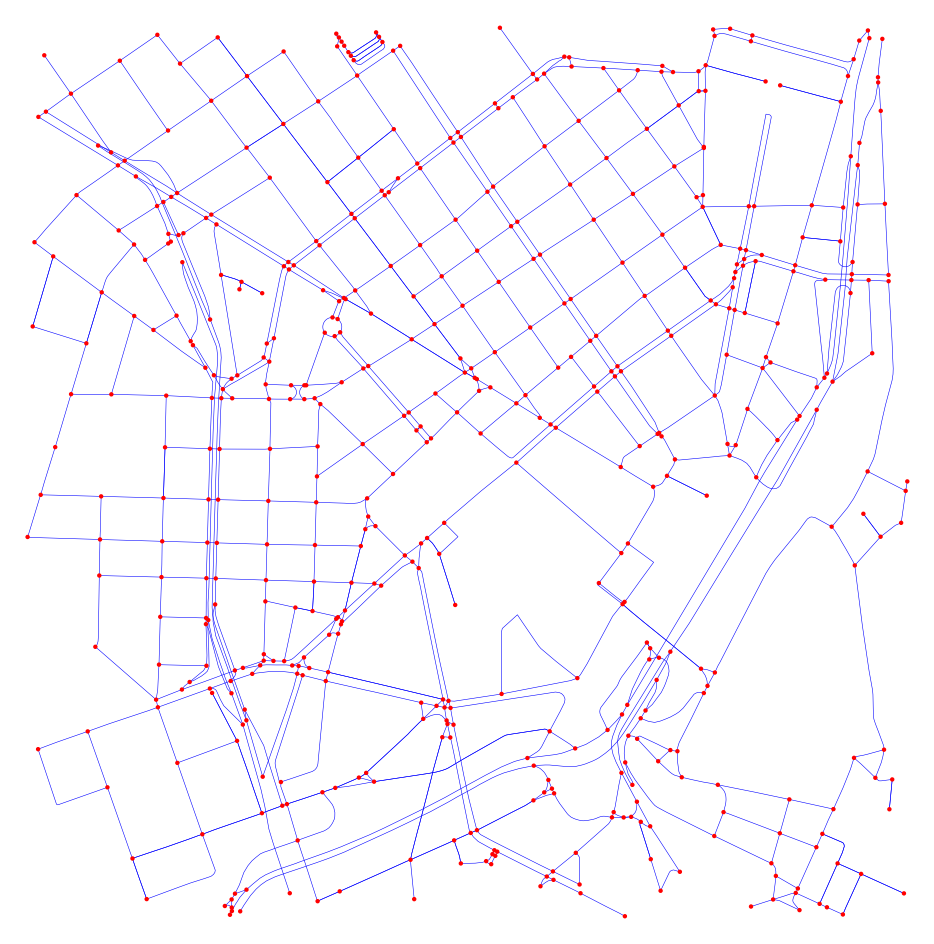

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

In [3]:
ox.plot_graph(g, bgcolor="white", node_size=10, edge_color="blue", node_color="red", edge_linewidth=0.4, figsize=(12, 12), dpi=300)

In [7]:
# faça um laço randomico de 0 a 5
import random
g = ox.truncate.largest_component(g, strongly=True)
random_nodes = random.sample(list(g.nodes()), 5)

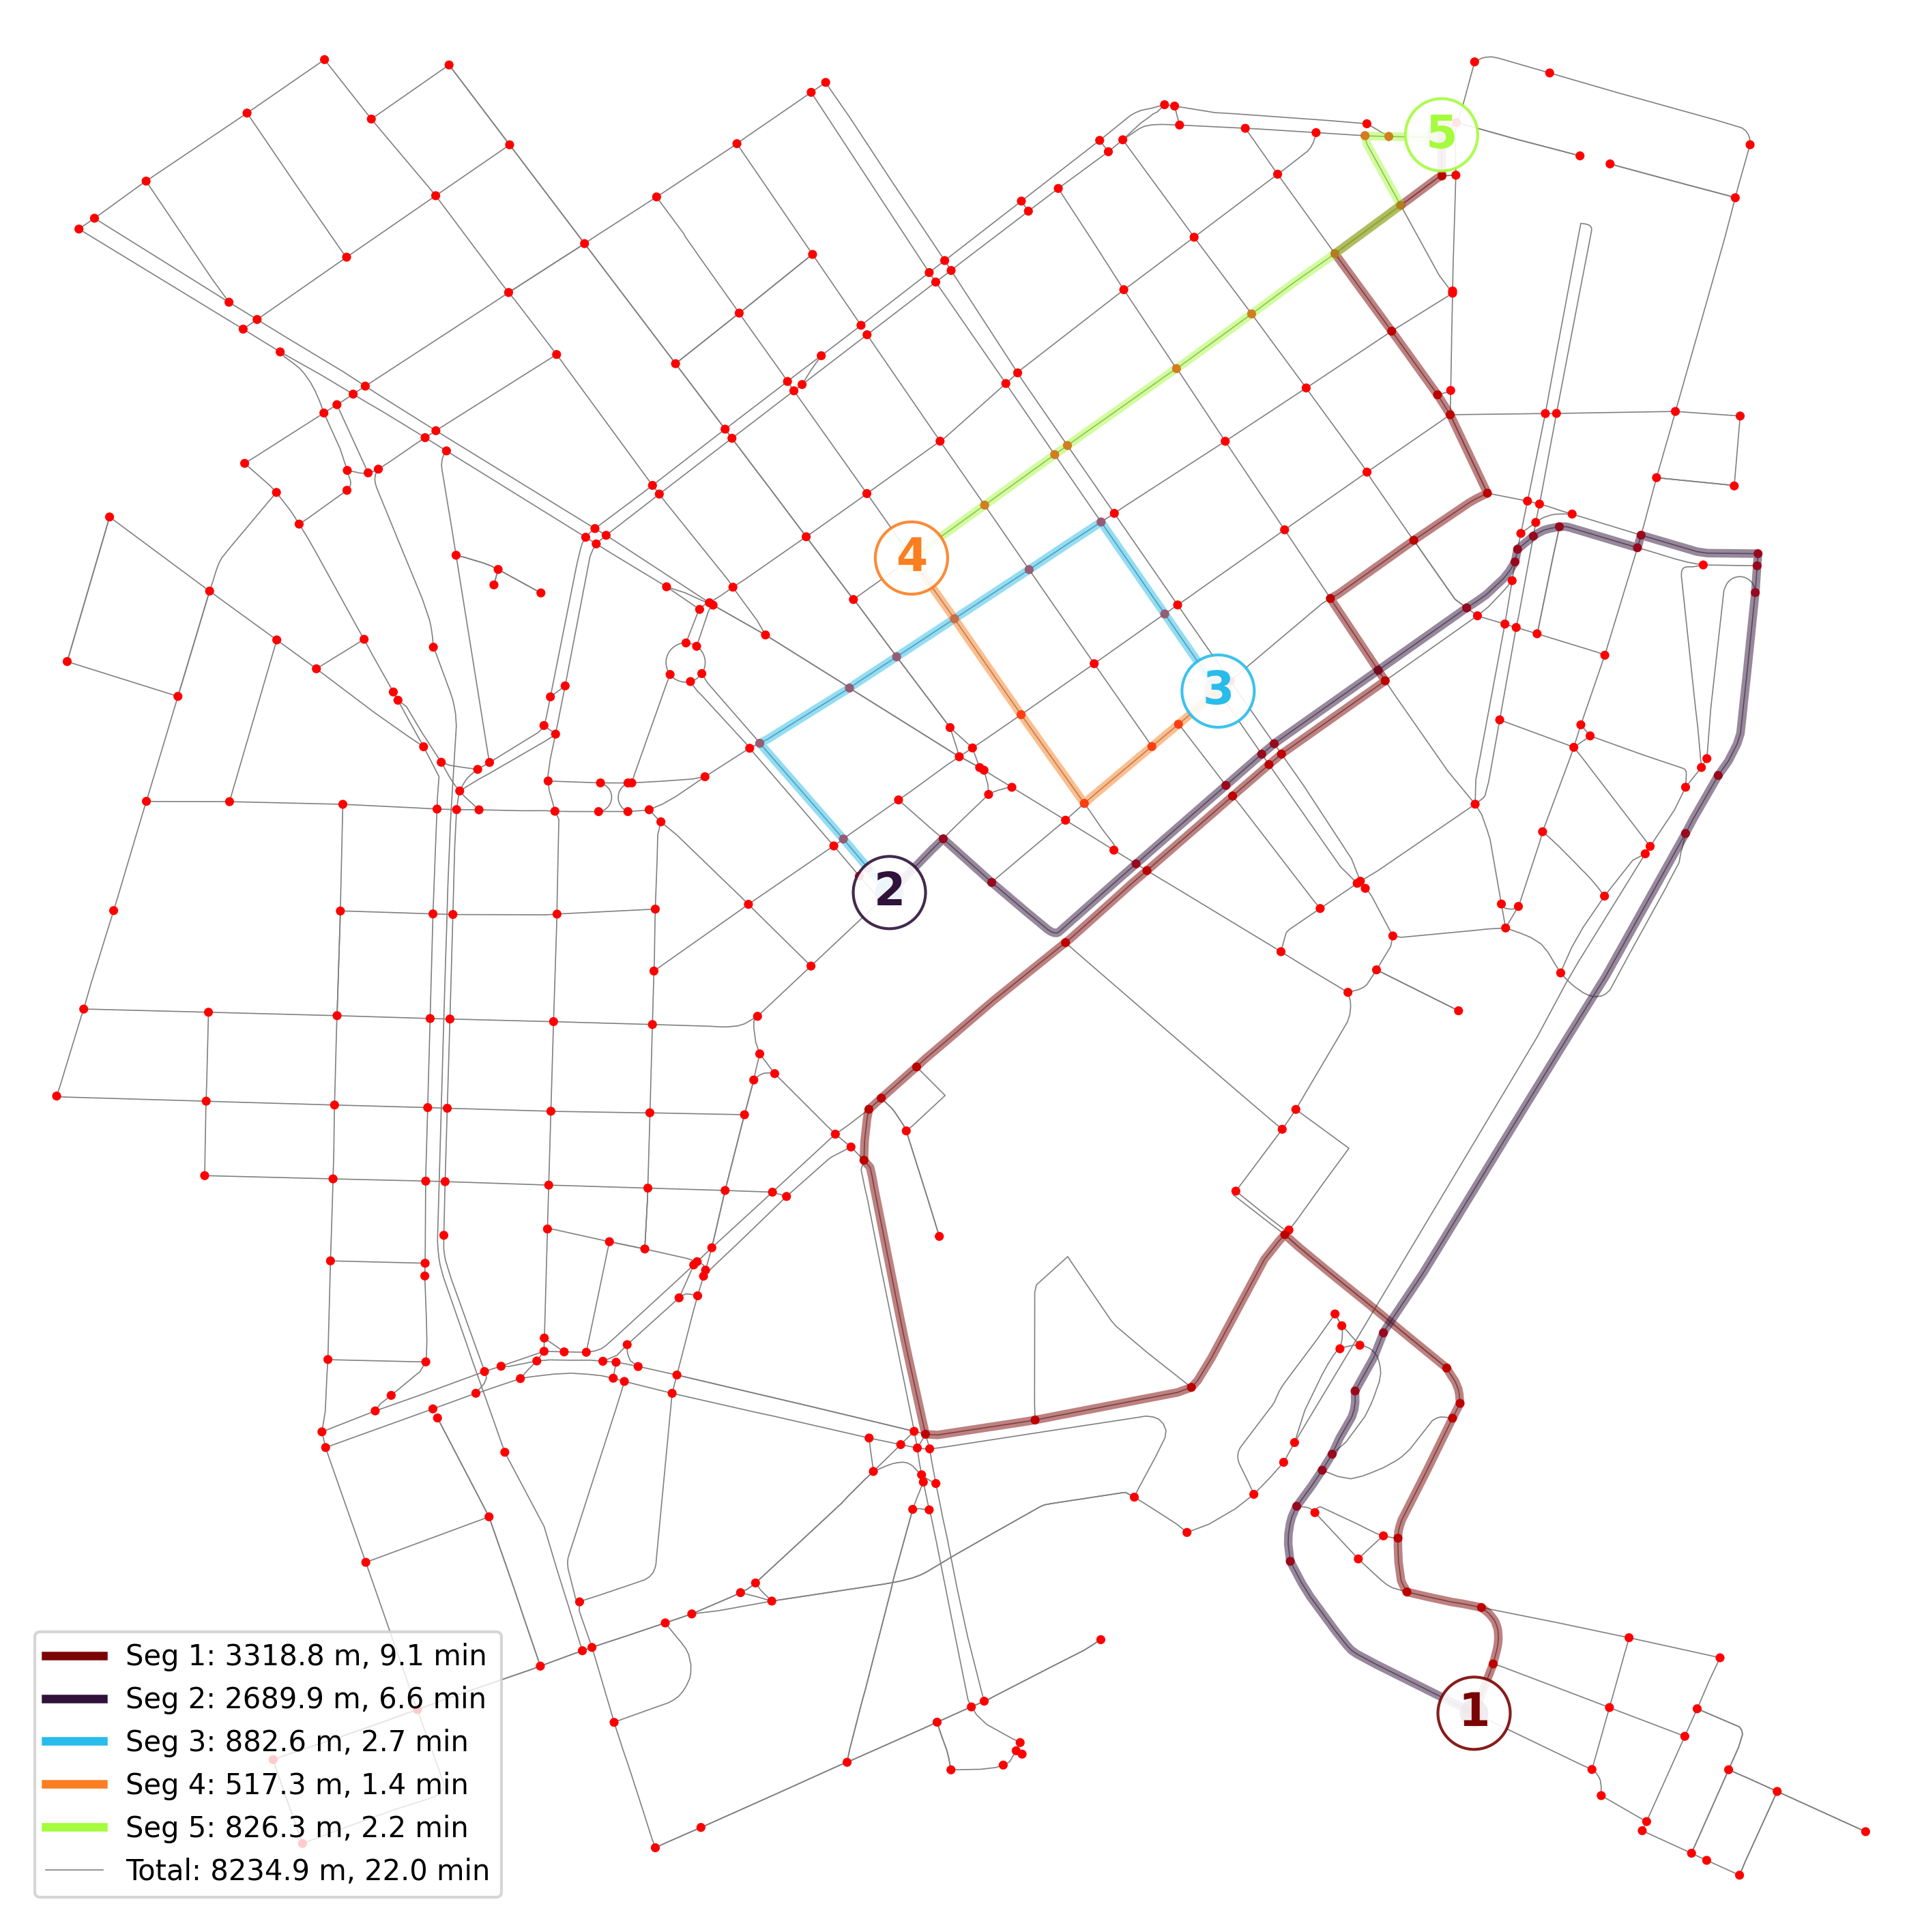

In [8]:
from route_plot_utils import compute_route_segments_info, plot_route_segments_info, weight_function

segments_info = compute_route_segments_info(g, random_nodes, weight_function)

plot_route_segments_info(g, segments_info)

In [ ]:
gdf = ox.graph_to_gdfs(g, nodes=False, edges=True)

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 930 entries, (np.int64(20944551), np.int64(20944552), np.int64(0)) to (np.int64(12162481296), np.int64(4221682838), np.int64(0))
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   osmid     930 non-null    object  
 1   highway   930 non-null    object  
 2   name      884 non-null    object  
 3   surface   930 non-null    object  
 4   oneway    930 non-null    bool    
 5   reversed  930 non-null    object  
 6   length    930 non-null    float64 
 7   geometry  930 non-null    geometry
 8   maxspeed  384 non-null    object  
dtypes: bool(1), float64(1), geometry(1), object(6)
memory usage: 71.9+ KB


In [ ]:
gdf.head()

osmid      highway  \
u        v          key                                                   
20944551 20944552   0                              8307075  residential   
         158844513  0                            914039011     tertiary   
20944552 20944551   0                              8307075  residential   
25928438 2021790380 0    [191591089, 866553011, 191591092]    secondary   
25928439 25928388   0                            191591086    secondary   

                                            name  surface  oneway reversed  \
u        v          key                                                      
20944551 20944552   0              Rua Fortunato  asphalt   False    False   
         158844513  0    Rua Frederico Abranches  asphalt    True    False   
20944552 20944551   0              Rua Fortunato  asphalt   False     True   
25928438 2021790380 0      Rua Brigadeiro Tobias  asphalt    True    False   
25928439 25928388   0         Avenida Tiradentes  asphalt    True    False   

                             length  \
u        v          key               
20944551 20944552   0    164.142379   
         158844513  0    135.690412   
20944552 20944551   0    164.142379   
25928438 2021790380 0     60.001610   
25928439 25928388   0     86.895016   

                                                                  geometry  \
u        v          key                                                      
20944551 20944552   0    LINESTRING (-46.65132 -23.53889, -46.65133 -23...   
         158844513  0    LINESTRING (-46.65132 -23.53889, -46.65119 -23...   
20944552 20944551   0    LINESTRING (-46.65178 -23.54031, -46.65176 -23...   
25928438 2021790380 0    LINESTRING (-46.63379 -23.53525, -46.6338 -23....   
25928439 25928388   0    LINESTRING (-46.63313 -23.53527, -46.6331 -23....   

                        maxspeed  
u        v          key           
20944551 20944552   0        NaN  
         158844513  0        NaN  
20944552 20944551   0        NaN  
25928438 2021790380 0         50  
25928439 25928388   0         50

In [ ]:
gdf.oneway.value_counts()

oneway
True     768
False    162
Name: count, dtype: int64

In [ ]:
gdf.surface.value_counts()

surface
asphalt                860
concrete                29
paved                   22
cobblestone             10
[asphalt, paved]         6
[asphalt, concrete]      3
Name: count, dtype: int64

In [ ]:
gdf.reversed.value_counts()

reversed
False            848
True              80
[False, True]      2
Name: count, dtype: int64

In [ ]:
ndf = ox.graph_to_gdfs(g, nodes=True, edges=False)
ndf.head()

,y,x,street_count,highway,ref,geometry
osmid,,,,,,
20944551,-23.538894,-46.651323,3,NaN,NaN,POINT (-46.65132 -23.53889)
20944552,-23.540311,-46.651775,4,NaN,NaN,POINT (-46.65178 -23.54031)
25928388,-23.534495,-46.633032,3,NaN,NaN,POINT (-46.63303 -23.5345)
25928438,-23.535247,-46.633790,3,NaN,NaN,POINT (-46.63379 -23.53525)
25928439,-23.535271,-46.633129,3,NaN,NaN,POINT (-46.63313 -23.53527)


In [ ]:
ndf.highway.value_counts()

highway
traffic_signals      223
crossing               3
turning_circle         2
motorway_junction      2
Name: count, dtype: int64

In [ ]:
print(g.nodes[2021790380].get("highway"))

traffic_signals
